In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading & Cleaning
The dataset is first inspected for formatting issues before being loaded into a pandas DataFrame. The data column is converted into datetime format, numerical values are verified, and the dataset is checked for missing values, duplicate records, and invalid entries

In [23]:
#printing the problematic lines
with open("daily-minimum-temperatures-in-me.csv","r") as f:
    for i, line in enumerate(f, start =1):
        if len(line.strip().split(","))!=2:
             print(f"Problem at line{i}:{line}")

Problem at line1:"Date","Daily minimum temperatures in Melbourne, Australia, 1981-1990"



In [24]:
#removing the unwanted lines
with open("daily-minimum-temperatures-in-me.csv","r") as f:
    lines =f.readlines()
with open("daily-minimum-temperatures-in-me.csv","w") as f:
    f.writelines(lines[:3651])
    
    

In [25]:
#load the data set
df = pd.read_csv("daily-minimum-temperatures-in-me.csv")
display(df.head())
display(df.tail())

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
3649,1990-12-31,13.0


In [26]:
#check the shape
print(df.shape)
#converting date time
df['Date'] = pd.to_datetime(df['Date'])
#Data types
print(df.dtypes)
#check for missing values
print(df.isnull().sum())
#check for duplicated rows
print(df.duplicated().sum())
#check for invalid values
df.describe()

(3650, 2)
Date                                                             datetime64[ns]
Daily minimum temperatures in Melbourne, Australia, 1981-1990            object
dtype: object
Date                                                             0
Daily minimum temperatures in Melbourne, Australia, 1981-1990    0
dtype: int64
0


,Date
count,3650
mean,1985-12-31 07:12:00
min,1981-01-01 00:00:00
25%,1983-07-02 06:00:00
50%,1985-12-31 12:00:00
75%,1988-06-30 18:00:00
max,1990-12-31 00:00:00


In [27]:
df.rename(columns ={"Daily minimum temperatures in Melbourne, Australia, 1981-1990": "Temperature"},inplace = True)
df.columns

Index(['Date', 'Temperature'], dtype='object')

In [28]:
df['Temperature'] = pd.to_numeric(df['Temperature'],errors ="coerce")
print(df.dtypes)

Date           datetime64[ns]
Temperature           float64
dtype: object


In [29]:
Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1- 1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = df[(df['Temperature']<lower_bound)|(df['Temperature']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers[['Date','Temperature']]

Number of outliers: 13


,Date,Temperature
14,1981-01-15,25.0
17,1981-01-18,24.8
39,1981-02-09,25.0
381,1982-01-17,24.0
384,1982-01-20,25.2
403,1982-02-08,22.7
409,1982-02-14,22.8
410,1982-02-15,26.3
1425,1984-11-26,24.3
2495,1987-11-02,23.0


Outlier Analysis:
The IQR (Interquartile Range) method identified 13 potential outliers in the temperature data. On inspection, these values ranged from 22.7°C to 26.3°C and occurred mainly during the warmer months. Since these temperatures are realistic for Melbourne and represent genuine climatic variations rather than data entry or measurement errors, the outliers were retained in the dataset for subsequent analysis and model development.

## 2. Time Series Visualization
Visualizing the temperature values helps identify long-term trends, seasonality, and unusual behaviour before building the forecasting model

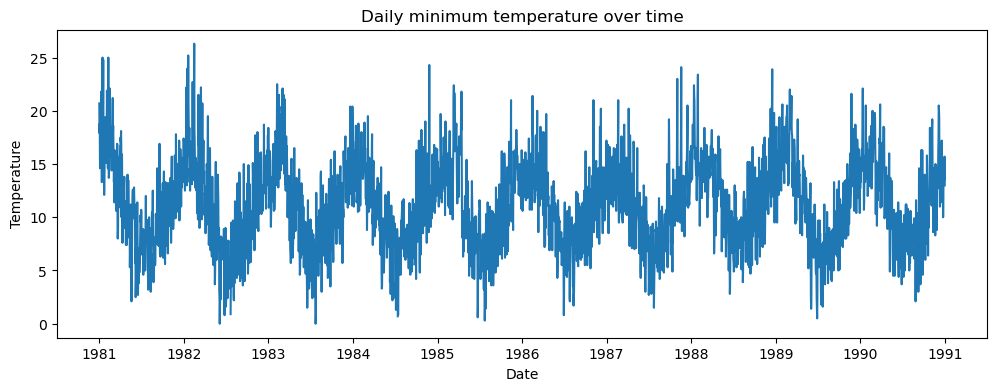

In [30]:
#time series plot
plt.figure(figsize =(12,4))
plt.plot(df['Date'],df['Temperature'])
plt.title("Daily minimum temperature over time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

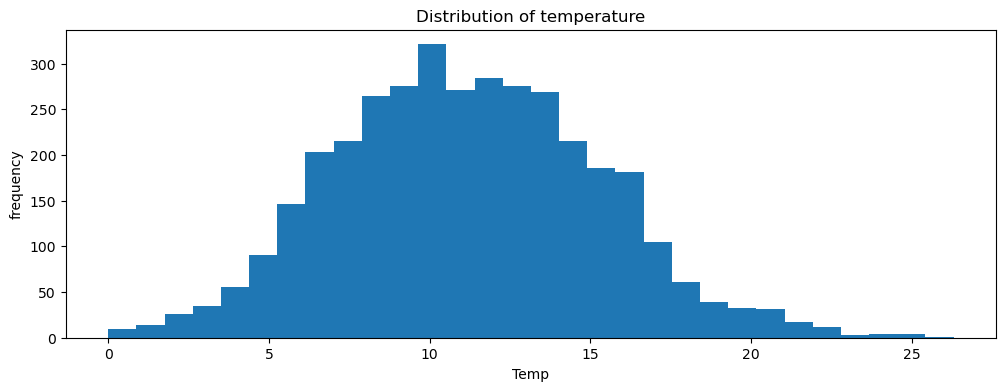

In [31]:
#histogram
plt.figure(figsize =(12,4))
plt.hist(df['Temperature'],bins =30)
plt.title("Distribution of temperature")
plt.xlabel("Temp")
plt.ylabel("frequency")
plt.show()

Histogram Analysis:
The histogram shows that the daily minimum temperatures are approximately bell-shaped, indicating an approximately normal distribution. Most temperature values are concentrated between 6°C and 16°C, with the highest frequency around 10–12°C. A slight positive (right) skew is observed due to a few higher temperature values, which is consistent with the outliers detected using the IQR method.

In [32]:
df['Temperature'].isna().sum()
df[df['Temperature'].isna()]
df['Temperature'] = df['Temperature'].interpolate(method ="linear")


## 3. Stationarity Test
The Augmented Dickey-Fuller (ADF) test is performed to determine whether the time series is stationary. A stationary series satisfies one of the important assumptions for autoregressive modelling

In [33]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Temperature'])
print("ADF Statistic :", result[0])
print("p-value",result[1])
print("Number of lags used:",result[2])
print("Number of observations:",result[3])
print("\n critical values:")
for key,value in result[4].items():
    print(f"{key}:{value}")

ADF Statistic : -4.440522006557903
p-value 0.00025147236020338674
Number of lags used: 20
Number of observations: 3629

 critical values:
1%:-3.4321532327220154
5%:-2.862336767636517
10%:-2.56719413172842


## 4. Train-Test Split
The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used for learning model parameters, while the testing set is reserved for evaluating forecasting performance

In [34]:
#Train_Test split
train_size = int(len(df)*0.8)
train =df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()
print("training Samples:",len(train))
print("testing samples:",len(test))

training Samples: 2920
testing samples: 730


## 5. Selecting the Lag Order
The number of previous observations used as inputs to the ARNN model is called the lag order(u)

In [35]:
#find lag: how many prev temp values should i use to predict the next temperature?
#optimal lag using AIC
from statsmodels.tsa.ar_model import AutoReg
aic_values=[]
max_lag =30
for lag in range(1,max_lag+1):
    model = AutoReg(train['Temperature'],lags = lag).fit()
    aic_values.append((lag,model.aic))
#find lag with min AIC
best_lag,best_aic = min(aic_values,key = lambda x:x[1])
print("Best Lag:",best_lag)
print("Best AIC:",best_aic)

Best Lag: 30
Best AIC: 13416.494024569609


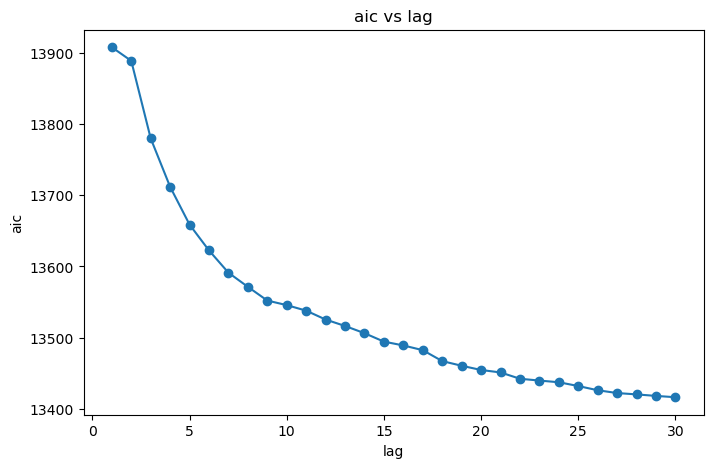

In [36]:
#plot the AIC Values
lags = [x[0] for x in aic_values]
aics = [x[1] for x in aic_values]
plt.figure(figsize=(8,5))
plt.plot(lags,aics,marker ='o')
plt.xlabel("lag")
plt.ylabel("aic")
plt.title("aic vs lag")
plt.show()

In [37]:
from statsmodels.tsa.ar_model import AutoReg
aic_values=[]
max_lag =100
for lag in range(1,max_lag+1):
    model = AutoReg(train['Temperature'],lags = lag).fit()
    aic_values.append((lag,model.aic))
#find lag with min AIC
best_lag,best_aic = min(aic_values,key = lambda x:x[1])
print("Best Lag:",best_lag)
print("Best AIC:",best_aic)

Best Lag: 100
Best AIC: 13086.30633650306


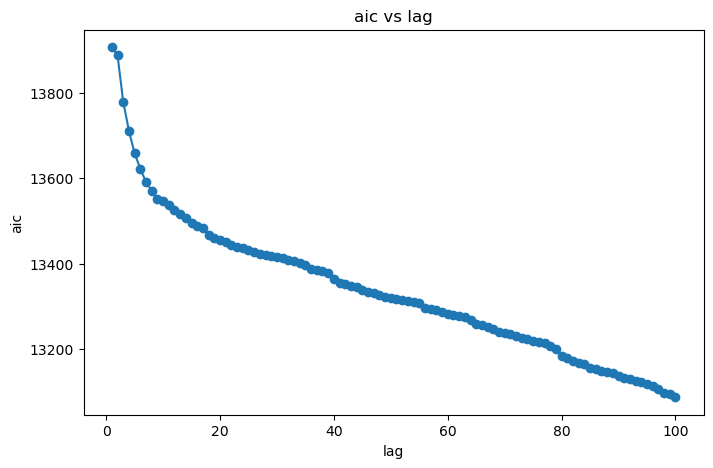

In [38]:
#plot the AIC Values
lags = [x[0] for x in aic_values]
aics = [x[1] for x in aic_values]
plt.figure(figsize=(8,5))
plt.plot(lags,aics,marker ='o')
plt.xlabel("lag")
plt.ylabel("aic")
plt.title("aic vs lag")
plt.show()

AIC is getting over fitted, AIC alone is not giving a unique optimal lag

<Figure size 1000x500 with 0 Axes>

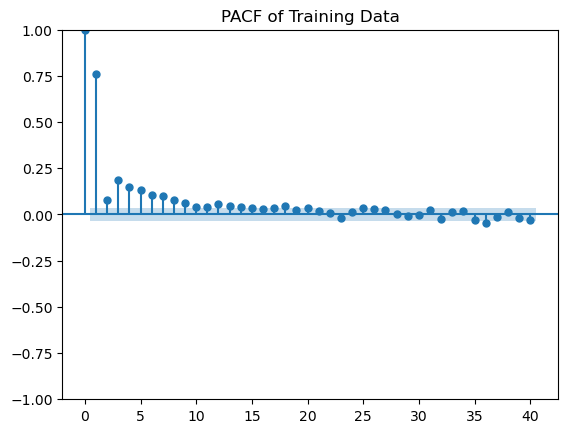

In [39]:
#PACF
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize =(10,5))
plot_pacf(train['Temperature'],lags = 40, method ="ywm")
plt.title("PACF of Training Data")
plt.show()

Minimum reasonable choice: u=8
Most balanced choice: u=10 
Upper reasonable choice: u=12

The Partial Autocorrelation Function (PACF) was plotted using the training dataset to determine the appropriate autoregressive lag order. The PACF showed significant spikes up to approximately lag 10, after which the partial correlations became negligible. Therefore, the lag order was selected as u = 10. According to the ARNN architecture, the number of hidden neurons was computed as v=⌈(u+1)/2⌉=⌈11/2⌉=6. Hence, the final model architecture used in this study is ARNN(10,6).

Intially, the optimal lag was explored using AIC. However, AIC continued decreasing as the lag increased, indicating that relying solely on AIC could lead to overfitting. The PACF was also examined. Based on the significant PACF spikes, u=10 was selected as the final lag order

## 6. Feature Engineering
Lagged temperature values are created to transform the time series forecasting problem into a supervised learning problem

In [40]:
import math
u =10 # number of lagged inputs
v = math.ceil((u+1)/2)
print("number of lagged inputs (u):",u)
print("number of hidden neurons (v):",v)
print(f"ARNN architecture : ARNN({u},{v})")
              

number of lagged inputs (u): 10
number of hidden neurons (v): 6
ARNN architecture : ARNN(10,6)


In [41]:
#create lag features
u =10
for i in range(1,u+1):
    train[f"Lag_{i}"] = train['Temperature'].shift(i)
train.head(15)    

,Date,Temperature,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
0,1981-01-01,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1981-01-02,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1981-01-03,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1981-01-04,14.6,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1981-01-05,15.8,14.6,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN
5,1981-01-06,15.8,15.8,14.6,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN
6,1981-01-07,15.8,15.8,15.8,14.6,18.8,17.9,20.7,NaN,NaN,NaN,NaN
7,1981-01-08,17.4,15.8,15.8,15.8,14.6,18.8,17.9,20.7,NaN,NaN,NaN
8,1981-01-09,21.8,17.4,15.8,15.8,15.8,14.6,18.8,17.9,20.7,NaN,NaN
9,1981-01-10,20.0,21.8,17.4,15.8,15.8,15.8,14.6,18.8,17.9,20.7,NaN


In [42]:
train = train.dropna()
train.head(15)

,Date,Temperature,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
10,1981-01-11,16.2,20.0,21.8,17.4,15.8,15.8,15.8,14.6,18.8,17.9,20.7
11,1981-01-12,13.3,16.2,20.0,21.8,17.4,15.8,15.8,15.8,14.6,18.8,17.9
12,1981-01-13,16.7,13.3,16.2,20.0,21.8,17.4,15.8,15.8,15.8,14.6,18.8
13,1981-01-14,21.5,16.7,13.3,16.2,20.0,21.8,17.4,15.8,15.8,15.8,14.6
14,1981-01-15,25.0,21.5,16.7,13.3,16.2,20.0,21.8,17.4,15.8,15.8,15.8
15,1981-01-16,20.7,25.0,21.5,16.7,13.3,16.2,20.0,21.8,17.4,15.8,15.8
16,1981-01-17,20.6,20.7,25.0,21.5,16.7,13.3,16.2,20.0,21.8,17.4,15.8
17,1981-01-18,24.8,20.6,20.7,25.0,21.5,16.7,13.3,16.2,20.0,21.8,17.4
18,1981-01-19,17.7,24.8,20.6,20.7,25.0,21.5,16.7,13.3,16.2,20.0,21.8
19,1981-01-20,15.5,17.7,24.8,20.6,20.7,25.0,21.5,16.7,13.3,16.2,20.0


In [43]:
#creating input matrix and target vector 
lag_colums = [f"Lag_{i}" for i in range(1,u+1)]
X_train = train[lag_colums]
Y_train = train["Temperature"]
print("Shape of X_train:", X_train.shape)
print("Shape of Y_train :",Y_train.shape)

Shape of X_train: (2910, 10)
Shape of Y_train : (2910,)


## 7. Data Normalisation
Min-Max normalisation is applied separately to the input features and target variable to improve training stability and convergence.

In [44]:
#normalize x_train
X_min = X_train.min()
X_max = X_train.max()
X_train_norm = (X_train - X_min)/(X_max - X_min)
X_train_norm.head()

,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10
10,0.760456,0.828897,0.661597,0.600760,0.600760,0.600760,0.555133,0.714829,0.680608,0.787072
11,0.615970,0.760456,0.828897,0.661597,0.600760,0.600760,0.600760,0.555133,0.714829,0.680608
12,0.505703,0.615970,0.760456,0.828897,0.661597,0.600760,0.600760,0.600760,0.555133,0.714829
13,0.634981,0.505703,0.615970,0.760456,0.828897,0.661597,0.600760,0.600760,0.600760,0.555133
14,0.817490,0.634981,0.505703,0.615970,0.760456,0.828897,0.661597,0.600760,0.600760,0.600760


In [45]:
# normalize y_train
Y_min = Y_train.min()
Y_max = Y_train.max()
Y_train_norm = (Y_train-Y_min)/(Y_max -Y_min)
print(Y_train_norm.head())

10    0.615970
11    0.505703
12    0.634981
13    0.817490
14    0.950570
Name: Temperature, dtype: float64


## 8. ARNN Model Initialization
The ARNN architecture consists of :
Input neurons =10
Hidden neurons =6
Output neuron =1
weights are initilalized using small random values, while biases are intialized to zero.

In [46]:
#initialize weights and bias
np.random.seed(42)
input_neurons =10
hidden_neurons =6
output_neurons =1
#intilase input -> hidden weights
w1 = np.random.randn(input_neurons,hidden_neurons)*0.01
#initialize hidden layer biases
b1 = np.zeros((1,hidden_neurons))
#initialize hidden -> output weights
w2 = np.random.randn(hidden_neurons,output_neurons)*0.01
#initliase output bias
b2 = np.zeros((1,output_neurons))
print("W1 shape:", w1.shape)
print("b1 shape :", b1.shape)
print("W2 shape :", w2.shape)
print("b2 shape :", b2.shape)

W1 shape: (10, 6)
b1 shape : (1, 6)
W2 shape : (6, 1)
b2 shape : (1, 1)


Weights are initialized with small random values to break symmetry. If all weights are initialized to zero, every hidden neuron produces the same output and receives the same gradient during backpropagation. As a result, all neurons learn the same features, reducing the network to effectively a single neuron. Random initialization allows different neurons to learn different patterns from the data.

W1 = all weights between Input → Hidden
b1 = biases of the Hidden layer
W2 = all weights between Hidden → Output
b2 = bias of the Output layer

## 9. Forward Propagation
Forward propagation computes the predicted temperature by passing the normalised inputs through the hidden layer using the Leaky ReLU activation function, followed by a linear output neuron. 

In [47]:
#forward propagation 1.compute z1 = XW1+b1
Z1 = np.dot(X_train_norm,w1)+b1
print(Z1.shape)
def leaky_relu(z,alpha =0.01):
    return np.where(z>0,z,alpha*z)#np.where(condition,value_if_true,value_if_false)
A1 = leaky_relu(Z1)
print(A1.shape)
Z2 = np.dot(A1,w2)+b2
print(Z2.shape)
y_pred =Z2

(2910, 6)
(2910, 6)
(2910, 1)


In [48]:
#compute loss as this is regression we can use mean squared error
print(Y_train_norm.shape) # 1d array
print(y_pred.shape )#2d array

(2910,)
(2910, 1)


## 10. Loss Function
The prediction error is measured using MSE, which computes the average squared difference between the actual and predicted temperatures. The computed loss is used during backpropagation to update the network weights and biases.

In [49]:
#for subtraction lets make them same shape
Y_train_norm = Y_train_norm.values.reshape(-1,1)
print(Y_train_norm.shape)
print(y_pred.shape)
#error
error= Y_train_norm - y_pred
squared_error= error**2
loss = np.mean(squared_error)
print("MSE loss:",loss)

(2910, 1)
(2910, 1)
MSE loss: 0.20126502721870385


## 11. Backpropagation
The MSE loss function is minimised using Gradient Descent. Gradients are computed using the chain rule, and the weights and biases are updated iteratively.

In [50]:
# back propagation computing dl/dy^
m = X_train_norm.shape[0]
dz2 = (2/m)*(y_pred -Y_train_norm)
print("Number of Training samples(m):",m)
print("shape of dz2:",dz2.shape)
print(dz2[:5])
#updating w2 and b2 
dw2 = np.dot(A1.T,dz2)
db2 = np.sum(dz2,axis =0,keepdims = True)
print(dw2.shape)
print(db2.shape)
print(dw2)
print(db2)
#compute da1
da1 = np.dot(dz2,w2.T)
print(da1.shape)
print(da1[:5])
#compute dz1
def leaky_relu_derivative(z,alpha =0.01):
    return np.where(z>0,1,alpha)
dZ1 = da1*leaky_relu_derivative(Z1)
print(dZ1.shape)
print(dZ1[:5])
#compute dw1,db1
dw1 = np.dot(X_train_norm.T,dZ1)
db1 = np.sum(dZ1,axis =0,keepdims=True)
print(dw1.shape)
print(db1.shape)

Number of Training samples(m): 2910
shape of dz2: (2910, 1)
[[-0.0004234 ]
 [-0.00034761]
 [-0.00043644]
 [-0.00056187]
 [-0.00065334]]
(6, 1)
(1, 1)
[[-6.68952747e-03]
 [ 1.45826052e-04]
 [ 1.73922893e-04]
 [-1.35041779e-04]
 [ 5.51760419e-05]
 [-2.92535101e-04]]
[[-0.8429898]]
(2910, 6)
[[ 2.02882575e-06  7.86080893e-07  4.68422696e-06  5.06474391e-06
  -3.44023777e-06 -5.74232602e-06]
 [ 1.66564502e-06  6.45364306e-07  3.84570203e-06  4.15810252e-06
  -2.82439973e-06 -4.71439044e-06]
 [ 2.09131367e-06  8.10292218e-07  4.82850135e-06  5.22073824e-06
  -3.54619724e-06 -5.91918991e-06]
 [ 2.69231711e-06  1.04315466e-06  6.21612003e-06  6.72107827e-06
  -4.56530631e-06 -7.62025155e-06]
 [ 3.13065156e-06  1.21299001e-06  7.22816262e-06  7.81533279e-06
  -5.30858096e-06 -8.86089991e-06]]
(2910, 6)
[[ 2.02882575e-06  7.86080893e-09  4.68422696e-08  5.06474391e-08
  -3.44023777e-08 -5.74232602e-08]
 [ 1.66564502e-06  6.45364306e-09  3.84570203e-08  4.15810252e-08
  -2.82439973e-08 -4.714390

In [51]:
#Gradient descent update
learning_rate =0.01
w1 = w1-learning_rate*dw1
b1 = b1-learning_rate*db1
w2 = w2- learning_rate*dw2
b2 = b2 -learning_rate*db2

## 12. Model Training
The ARNN Model is trained for 500 epochs using Gradient Descent. During each epoch, forward propagation, loss computation, backpropagation, and parameter updates are performed.

In [52]:


# ==========================
# Activation Functions
# ==========================

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

# ==========================
# Prepare Target
# ==========================

Y_train_norm = Y_train_norm.reshape(-1, 1)

# ==========================
# Hyperparameters
# ==========================

epochs = 500
learning_rate = 0.01

# ==========================
# Training Loop
# ==========================

for epoch in range(epochs):

    # =====================================
    # 1. Forward Propagation
    # =====================================

    Z1 = np.dot(X_train_norm, w1) + b1
    A1 = leaky_relu(Z1)

    Z2 = np.dot(A1, w2) + b2
    y_pred = Z2        # Linear output layer

    # =====================================
    # 2. Compute Loss (MSE)
    # =====================================

    loss = np.mean((Y_train_norm - y_pred) ** 2)

    # =====================================
    # 3. Backpropagation
    # =====================================

    m = X_train_norm.shape[0]

    # Output Layer
    dZ2 = (2 / m) * (y_pred - Y_train_norm)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden Layer
    dA1 = np.dot(dZ2, w2.T)
    dZ1 = dA1 * leaky_relu_derivative(Z1)

    dW1 = np.dot(X_train_norm.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # =====================================
    # 4. Gradient Descent Update
    # =====================================

    w1 = w1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    w2 = w2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    # =====================================
    # Print Loss
    # =====================================

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss = {loss:.6f}")

print("\nTraining Completed!")
  

Epoch 50/500, Loss = 0.047155
Epoch 100/500, Loss = 0.026721
Epoch 150/500, Loss = 0.024013
Epoch 200/500, Loss = 0.023653
Epoch 250/500, Loss = 0.023604
Epoch 300/500, Loss = 0.023597
Epoch 350/500, Loss = 0.023595
Epoch 400/500, Loss = 0.023594
Epoch 450/500, Loss = 0.023592
Epoch 500/500, Loss = 0.023591

Training Completed!


## 13. Model Testing
The trained network is evaluated on unseen testing data to measure its forecasting capability.


In [53]:
#predict on test dataset
X_test =[]
Y_test =[]
test_values = test['Temperature'].values
for i in range(u,len(test_values)):
    X_test.append(test_values[i-u:i])
    Y_test.append(test_values[i])
X_test = np.array(X_test)
Y_test = np.array(Y_test)
print("X_test shape:",X_test.shape)
print("Y_test shape:",Y_test.shape)
    
    

X_test shape: (720, 10)
Y_test shape: (720,)


In [54]:
print(type(X_train))
print(type(X_test))
print(type(X_min))
print(X_min)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
Lag_1     0.0
Lag_2     0.0
Lag_3     0.0
Lag_4     0.0
Lag_5     0.0
Lag_6     0.0
Lag_7     0.0
Lag_8     0.0
Lag_9     0.0
Lag_10    0.0
dtype: float64


In [55]:
#converting the test data into a data frame
X_test = pd.DataFrame(X_test,columns =X_train.columns)
X_test_norm =(X_test -X_min)/(X_max - X_min)
Y_test_norm =(Y_test -Y_min)/(Y_max -Y_min)
Y_test_norm = Y_test_norm.reshape(-1,1)

In [56]:
#forward propgation on test data
Z1_test = np.dot(X_test_norm,w1) +b1 #The W1, W2, b1, and b2 you use for prediction are the final 
                                     #values after 500 epochs of training.
A1_test = leaky_relu(Z1_test)
Z2_test = np.dot(A1_test,w2)+b2
Y_pred_norm = Z2_test
print("Prediction shape:",Y_pred_norm.shape)

Prediction shape: (720, 1)


In [57]:
#inverse normalization
Y_pred = Y_pred_norm *(Y_max -Y_min)+Y_min
Y_actual = Y_test_norm *(Y_max -Y_min)+Y_min
print(Y_pred.shape)
print(Y_actual.shape)

(720, 1)
(720, 1)


## 14. Performance Evaluation
Model Performance is evaluated using RMSE and MAE. Finally, the predicted temperatures are compared with the actual observations using a line plot.

In [58]:
#evaluate the performance
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(Y_actual,Y_pred))
print("RMSE:",rmse)

RMSE: 4.115396493143262


In [59]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_actual,Y_pred)
print("MAE:",mae)

MAE: 3.3923643830868073


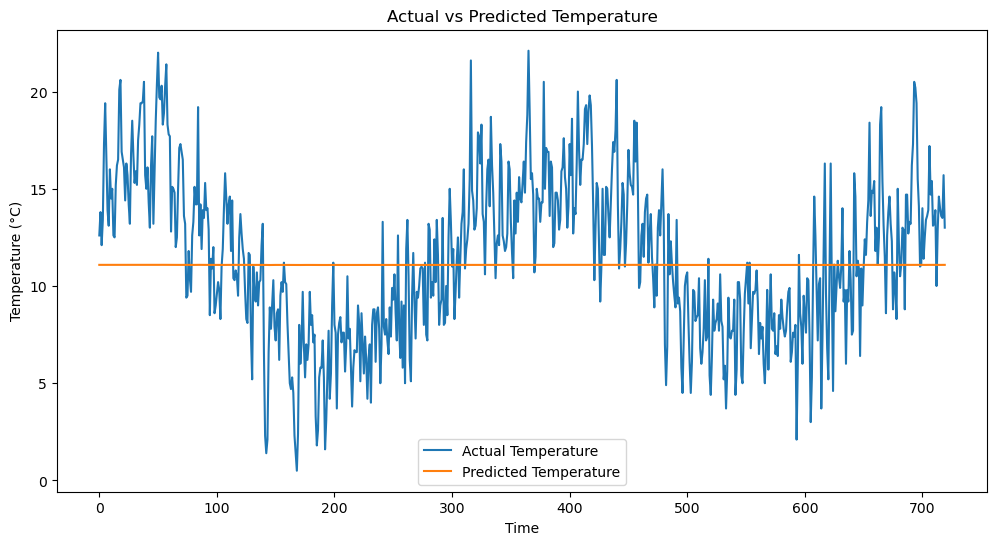

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(Y_actual, label="Actual Temperature")
plt.plot(Y_pred, label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

## 15. Conclusion
An ARNN(10,6) model was successfully implemented from scratch using Numpy. The model captured the general seasonal behaviour of the daily minimum temperature series. Although the predictions follow the overall trend, deviations remain during abrupt temperature changes, resulting in an RMSE of approximately 4.11 degree celusis and an MAE of 3.39 degree c. These results indicate that while ARNN is effective in modeling  nonlinear  patterns, there is still scope for improving forecasting accuracy. This motivates the use of PARNN which extends ARNN framework by incorporating probabilistic information to better model uncertainity and potentially improve forecasting performance.